## ASSIGNMENT 7: E-commerce Orders Analysis

In [10]:
import pandas as pd 
df=pd.read_csv('assignment7_ecommerce_orders(in).csv')
df

,OrderID,OrderDate,CustomerName,OrderStatus,ProductCategory,ItemQuantity,ItemPrice,ShippingCost,DiscountApplied,PaymentMethod,TotalAmount
0,10001,12/7/2024,Cust_1,Shipped,Electronics,15,265,0,0,UPI,3975
1,10002,7/12/2024,Cust_2,Shipped,Books,3,471,5,10,PayPal,1408
2,10003,6/10/2024,Cust_3,Pending,Home,19,236,5,10,Debit Card,4479
3,10004,12/12/2024,Cust_4,Shipped,Electronics,18,245,15,20,PayPal,4405
4,10005,12/26/2024,Cust_5,Cancelled,Home,8,370,0,5,UPI,2955
...,...,...,...,...,...,...,...,...,...,...,...
145,10146,5/25/2024,Cust_146,Completed,Electronics,9,141,10,5,PayPal,1274
146,10147,4/8/2024,Cust_147,Shipped,Home,3,113,0,20,Debit Card,319
147,10148,3/13/2024,Cust_148,Cancelled,Clothing,15,204,10,20,Credit Card,3050
148,10149,5/1/2024,Cust_149,Cancelled,Books,16,422,0,15,Credit Card,6737


In [15]:
df.head()

,OrderID,OrderDate,CustomerName,OrderStatus,ProductCategory,ItemQuantity,ItemPrice,ShippingCost,DiscountApplied,PaymentMethod,TotalAmount
0,10001,12/7/2024,Cust_1,Shipped,Electronics,15,265,0,0,UPI,3975
1,10002,7/12/2024,Cust_2,Shipped,Books,3,471,5,10,PayPal,1408
2,10003,6/10/2024,Cust_3,Pending,Home,19,236,5,10,Debit Card,4479
3,10004,12/12/2024,Cust_4,Shipped,Electronics,18,245,15,20,PayPal,4405
4,10005,12/26/2024,Cust_5,Cancelled,Home,8,370,0,5,UPI,2955


In [16]:
df.describe()

,OrderID,ItemQuantity,ItemPrice,ShippingCost,DiscountApplied,TotalAmount
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,10075.500000,10.193333,241.966667,7.466667,10.700000,2516.393333
std,43.445368,5.708461,145.138602,5.487835,7.212731,2192.349440
min,10001.000000,1.000000,12.000000,0.000000,0.000000,16.000000
25%,10038.250000,5.000000,121.750000,5.000000,5.000000,641.000000
50%,10075.500000,10.000000,235.000000,5.000000,10.000000,1899.000000
75%,10112.750000,15.000000,362.500000,10.000000,15.000000,3692.750000
max,10150.000000,19.000000,498.000000,15.000000,20.000000,9286.000000


## Q7.1: Data Loading and Verification
#### Load the e-commerce orders data and calculate the total order amount.

In [135]:
total=df['TotalAmount'].sum()
total

np.int64(377459)

In [136]:
print("E-commerce Orders Dataset:")
print(df.head(10))
print(f"\nTotal Orders: {len(df)}")
print(f"Total Amount: ${total:,.2f}")

E-commerce Orders Dataset:
   OrderID   OrderDate CustomerName OrderStatus ProductCategory  ItemQuantity  \
0    10001   12/7/2024       Cust_1     Shipped     Electronics            15   
1    10002   7/12/2024       Cust_2     Shipped           Books             3   
2    10003   6/10/2024       Cust_3     Pending            Home            19   
3    10004  12/12/2024       Cust_4     Shipped     Electronics            18   
4    10005  12/26/2024       Cust_5   Cancelled            Home             8   
5    10006   9/13/2024       Cust_6   Cancelled           Books            17   
6    10007   3/12/2024       Cust_7     Shipped     Electronics             8   
7    10008   3/27/2024       Cust_8     Shipped           Books             7   
8    10009   9/18/2024       Cust_9   Cancelled     Electronics             7   
9    10010    8/1/2024      Cust_10   Completed        Clothing             3   

   ItemPrice  ShippingCost  DiscountApplied PaymentMethod  TotalAmount  
0       

## Q7.2: Order Status Analysis
#### Filter completed orders and calculate average order value by payment method.

In [98]:
Filter=df[df['OrderStatus']=='Completed']
Filter

,OrderID,OrderDate,CustomerName,OrderStatus,ProductCategory,ItemQuantity,ItemPrice,ShippingCost,DiscountApplied,PaymentMethod,TotalAmount
9,10010,8/1/2024,Cust_10,Completed,Clothing,3,219,5,0,PayPal,662
18,10019,12/27/2024,Cust_19,Completed,Home,8,175,15,20,Debit Card,1395
22,10023,12/20/2024,Cust_23,Completed,Clothing,4,479,15,15,UPI,1916
28,10029,6/25/2024,Cust_29,Completed,Home,14,246,5,15,UPI,3434
31,10032,2/18/2024,Cust_32,Completed,Books,6,225,5,20,Debit Card,1335
33,10034,7/8/2024,Cust_34,Completed,Clothing,3,272,5,0,PayPal,821
34,10035,5/15/2024,Cust_35,Completed,Electronics,8,301,0,20,UPI,2388
38,10039,10/21/2024,Cust_39,Completed,Books,13,335,10,20,Debit Card,4345
50,10051,10/31/2024,Cust_51,Completed,Home,6,236,0,15,Debit Card,1401
51,10052,2/10/2024,Cust_52,Completed,Books,2,22,0,15,PayPal,29


In [32]:
print(f"Completed Orders:{len(Filter)}")

Completed Orders:39


In [71]:
avg_order=df.groupby('PaymentMethod')['TotalAmount'].agg(['mean','count']).reset_index()

In [72]:
print("Average Order Value by Payment Method:")
print(avg_order)

Average Order Value by Payment Method:
  PaymentMethod         mean  count
0   Credit Card  2866.166667     42
1    Debit Card  2421.843750     32
2        PayPal  2179.975610     41
3           UPI  2577.200000     35


## Q7.3: Category Summary
#### Create a summary showing order count and total revenue by product category

In [54]:
Category=df.groupby('ProductCategory').agg({'OrderID':'count',
                            'TotalAmount':'sum'}).rename(columns={'OrderID':'OrderCount','TotalAmount':'TotalRevenue'})

In [55]:
print('Category Summary:')
print(Category)

Category Summary:
                 OrderCount  TotalRevenue
ProductCategory                          
Books                    36         85079
Clothing                 32         80327
Electronics              45        115175
Home                     37         96878


## Q7.4: Payment Method Analysis
#### Identify the most common payment method and calculate its usage percentage

In [60]:
payment_count=df['PaymentMethod'].value_counts()
most_common_method=payment_count.idxmax()
most_common_count=payment_count.max()

In [63]:
percentage=(most_common_count/len(df))*100

In [73]:
print(f"Most Common Payment Method: {most_common_method} ({percentage:.1f}%)")
print("All Payment Methods:")
print(payment_count.reset_index())

Most Common Payment Method: Credit Card (28.0%)
All Payment Methods:
  PaymentMethod  count
0   Credit Card     42
1        PayPal     41
2           UPI     35
3    Debit Card     32


## Q7.5: Discount Analysis
#### Group orders by status and calculate average discount applied per status.

In [83]:
Discount=df.groupby('OrderStatus')['DiscountApplied'].agg(['mean','count','sum'])

In [84]:
print("Average Discount Summary by Status:")
print(Discount)

Average Discount Summary by Status:
                  mean  count  sum
OrderStatus                       
Cancelled     9.743590     39  380
Completed    12.051282     39  470
Pending      10.625000     32  340
Shipped      10.375000     40  415


## Q7.6: Pivot Analysis
#### Create a pivot table with OrderStatus as rows and PaymentMethod as columns (count of orders)

In [93]:
pivot=pd.pivot_table(data=df,index='OrderStatus',columns='PaymentMethod',values='OrderID',aggfunc='count')
print("Order Count for Status and PaymentMethod:")
pivot

Order Count for Status and PaymentMethod:


PaymentMethod,Credit Card,Debit Card,PayPal,UPI
OrderStatus,,,,
Cancelled,6,6,16,11
Completed,7,7,14,11
Pending,10,12,3,7
Shipped,19,7,8,6


In [94]:
pivot=pd.crosstab(df['OrderStatus'],df['PaymentMethod'])
print("Order Count for Status and PaymentMethod:")
pivot

Order Count for Status and PaymentMethod:


PaymentMethod,Credit Card,Debit Card,PayPal,UPI
OrderStatus,,,,
Cancelled,6,6,16,11
Completed,7,7,14,11
Pending,10,12,3,7
Shipped,19,7,8,6


## Q7.7: Order Export
#### Export all completed orders to completed_orders.csv with relevant columns.

In [96]:
Filter.to_csv('completed_orders.csv',index=False)

## Q7.8: Top Dates
#### Find the top 5 dates by total revenue.

In [104]:
top_dates=df.groupby('OrderDate')['TotalAmount'].sum().nlargest(5).reset_index()

In [106]:
print("Top_5 Dates by Total Revenue:")
print(top_dates)

Top_5 Dates by Total Revenue:
    OrderDate  TotalAmount
0   2/20/2024         9286
1   1/30/2024         8959
2   9/14/2024         8695
3   6/16/2024         8158
4  10/20/2024         7910


## Q7.9: Discount by Category
#### Calculate the average discount percentage by product category

In [116]:
Discount=df.groupby('ProductCategory')['DiscountApplied'].mean().reset_index()

In [117]:
print("Average Discount by Product Category:")
print(Discount)

Average Discount by Product Category:
  ProductCategory  DiscountApplied
0           Books        10.833333
1        Clothing         9.531250
2     Electronics        10.666667
3            Home        11.621622


## Q7.10: Visualizations
#### Create visualizations comparing order status and payment method distributions.

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns 

Text(0, 0.5, 'Number of Orders')

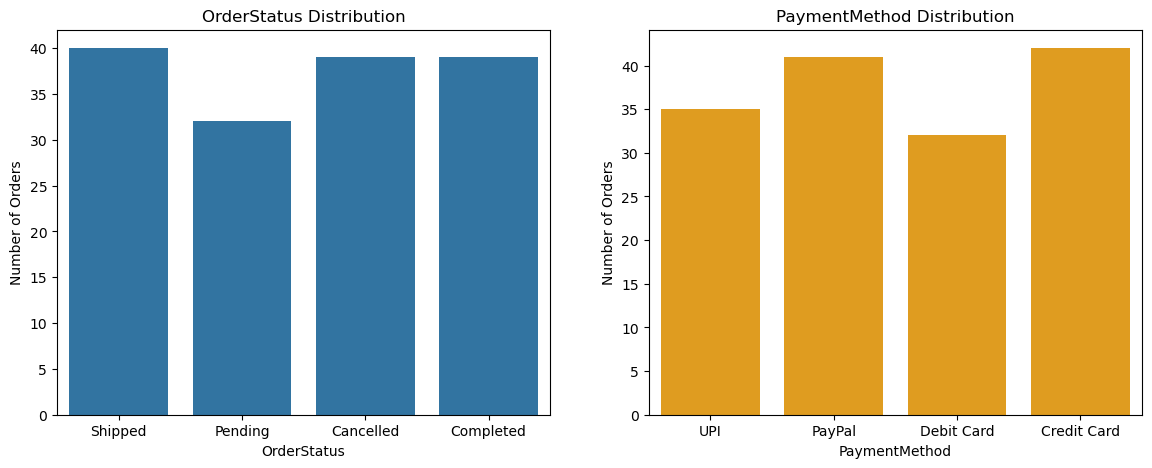

In [129]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df,x='OrderStatus',ax=ax1)
ax1.set_title('OrderStatus Distribution')
ax1.set_ylabel('Number of Orders')

sns.countplot(data=df,x='PaymentMethod',ax=ax2,color='orange')
ax2.set_title('PaymentMethod Distribution')
ax2.set_ylabel('Number of Orders')
